# Лабораторная работа №1 (CV): Проведение исследований с моделями классификации изображений

## Цель работы
Исследование архитектур нейронных сетей (сверточных и трансформерных) для задачи классификации МРТ-изображений мозга.

## Датасет: Brain Tumor MRI Dataset
Ссылка: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

Датасет содержит МРТ-изображения мозга 4 классов: **glioma**, **meningioma**, **notumor**, **pituitary**. Практическая задача — автоматическое распознавание типа опухоли мозга для поддержки медицинской диагностики.

## Метрики качества
- **Accuracy** – доля правильных ответов
- **Precision (macro)** – точность, усредненная по классам
- **Recall (macro)** – полнота, усредненная по классам
- **F1-Score (macro)** – гармоническое среднее точности и полноты
- **ROC-AUC (macro)** – площадь под ROC-кривой

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
set_seed(42)

Используемое устройство: cuda


## Загрузка данных

In [ ]:
data_dir = 'data/MPI_brain'
image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

def is_image_file(fname):
    return fname.lower().endswith(image_exts)

def list_class_folders(split_path):
    return sorted([
        d for d in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, d))
    ])

def count_images(folder):
    return sum(1 for f in os.listdir(folder) if is_image_file(f))

if not os.path.isdir(data_dir):
    raise FileNotFoundError(
        f"Папка {data_dir} не найдена. Скачайте Brain Tumor MRI Dataset и разместите его в этой директории."
    )

train_path = os.path.join(data_dir, 'Training')
val_path = os.path.join(data_dir, 'Testing')  # используем Testing как validation
test_path = os.path.join(data_dir, 'test')

for split_name, split_path in [('Training', train_path), ('Testing', val_path)]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Не найдена папка {split_name}: {split_path}")

# Собираем информацию о классах из папки train
classes = list_class_folders(train_path)
if not classes:
    raise ValueError(f"В папке {train_path} не найдено ни одной папки-класса.")

print("Классы:", classes)
print("Всего классов:", len(classes))

# Подсчёт изображений в train и val
train_counts = []
val_counts = []
for cls in classes:
    train_cls_path = os.path.join(train_path, cls)
    val_cls_path = os.path.join(val_path, cls)

    if not os.path.isdir(train_cls_path):
        raise FileNotFoundError(f"Не найдена папка класса в train: {train_cls_path}")
    if not os.path.isdir(val_cls_path):
        raise FileNotFoundError(f"Не найдена папка класса в validation: {val_cls_path}")

    train_counts.append(count_images(train_cls_path))
    val_counts.append(count_images(val_cls_path))

print(f"Всего изображений в train: {sum(train_counts)}")
print(f"Всего изображений в validation: {sum(val_counts)}")

Классы: ['glioma', 'meningioma', 'notumor', 'pituitary']
Всего классов: 4
Всего изображений в train: 5600
Всего изображений в validation: 1600


## Предварительный анализ данных

На этом этапе проверим структуру датасета, баланс классов, распределение размеров изображений, форматы файлов и базовую статистику яркости. Это позволит заранее понять, насколько данные однородны и какие преобразования нужны для обучения моделей.

Сводка по классам:


,Класс,Train,Validation,"Train, %","Validation, %",Train/Val
0,glioma,1400,400,25.0,25.0,3.5
1,meningioma,1400,400,25.0,25.0,3.5
2,notumor,1400,400,25.0,25.0,3.5
3,pituitary,1400,400,25.0,25.0,3.5


Итого train: 5600 изображений
Итого validation: 1600 изображений
Индекс дисбаланса train (max/min): 1.00
Индекс дисбаланса validation (max/min): 1.00

Распределение режимов изображений в train:


,Количество
mode,
RGB,3238
L,2358
RGBA,3
P,1


Статистика train по классам:


,images,width_mean,width_median,height_mean,height_median,mean_intensity,std_intensity
class,,,,,,,
glioma,1400,512.00,512.0,512.00,512.0,33.09,38.35
meningioma,1400,495.41,512.0,497.04,512.0,43.36,46.51
notumor,1400,313.55,230.0,327.36,244.0,61.73,60.65
pituitary,1400,513.09,512.0,512.66,512.0,49.43,41.55


Средняя ширина: 458.5 px
Средняя высота: 462.3 px
Медианная ширина: 512.0 px
Медианная высота: 512.0 px
Средняя яркость (mean_pixel): 46.91
Среднее стандартное отклонение яркости: 46.76


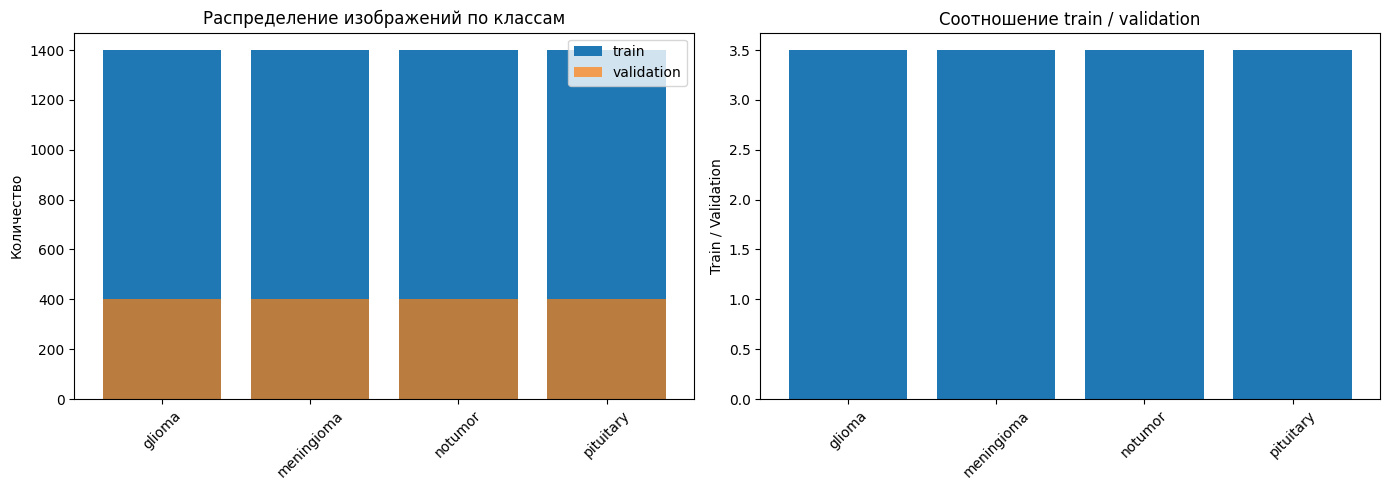

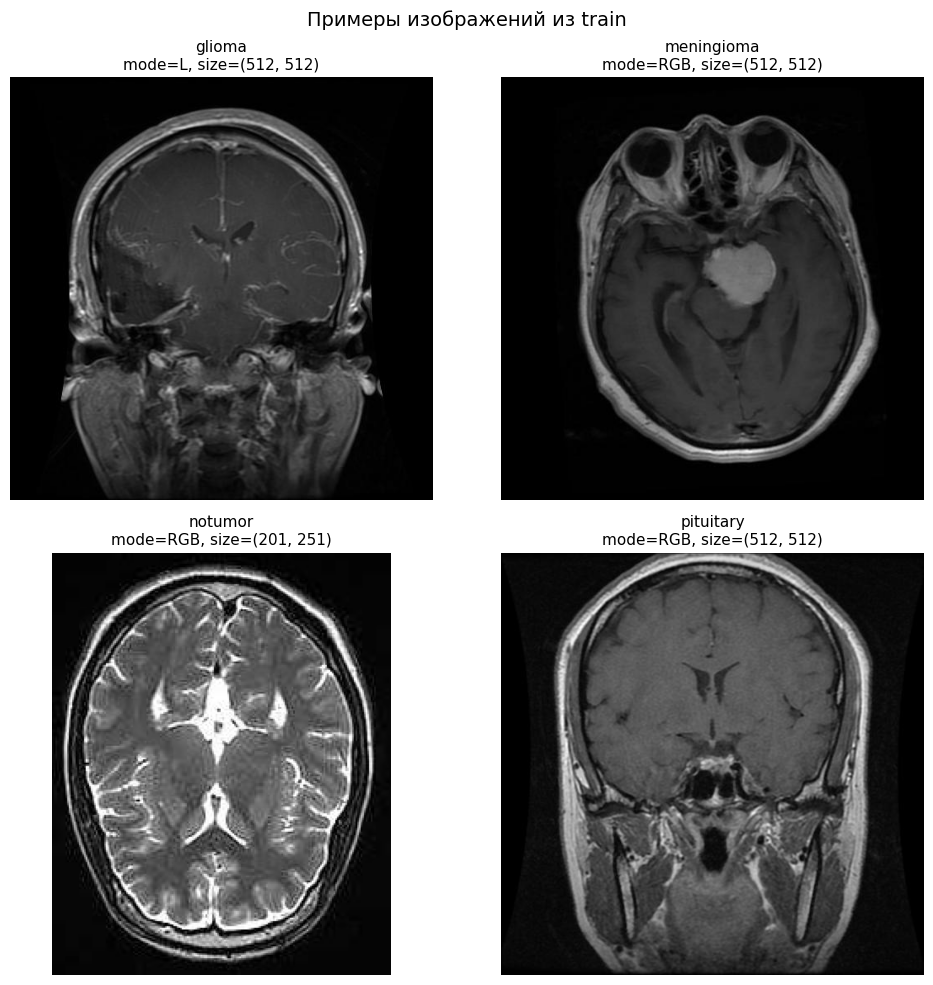

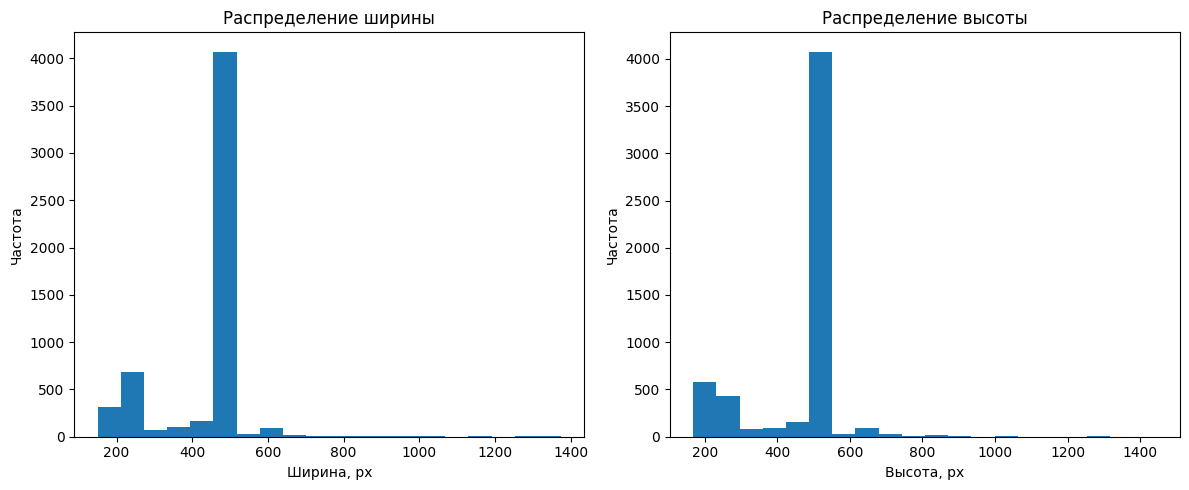

In [ ]:
from IPython.display import display

def scan_split(split_path):
    rows = []
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue

        for fname in os.listdir(cls_path):
            if not is_image_file(fname):
                continue

            fpath = os.path.join(cls_path, fname)
            try:
                with Image.open(fpath) as img:
                    rgb = img.convert("RGB")
                    arr = np.asarray(rgb)
                    rows.append({
                        "class": cls,
                        "file": fname,
                        "width": img.width,
                        "height": img.height,
                        "mode": img.mode,
                        "mean_pixel": float(arr.mean()),
                        "std_pixel": float(arr.std())
                    })
            except Exception:
                rows.append({
                    "class": cls,
                    "file": fname,
                    "width": np.nan,
                    "height": np.nan,
                    "mode": "ERROR",
                    "mean_pixel": np.nan,
                    "std_pixel": np.nan
                })
    return pd.DataFrame(rows)

train_stats = scan_split(train_path)
val_stats = scan_split(val_path)

summary_df = pd.DataFrame({
    "Класс": classes,
    "Train": train_counts,
    "Validation": val_counts
})
summary_df["Train, %"] = (summary_df["Train"] / summary_df["Train"].sum() * 100).round(2)
summary_df["Validation, %"] = (summary_df["Validation"] / summary_df["Validation"].sum() * 100).round(2)
summary_df["Train/Val"] = (summary_df["Train"] / summary_df["Validation"].replace(0, np.nan)).round(2)

print("Сводка по классам:")
display(summary_df)

print(f"Итого train: {len(train_stats)} изображений")
print(f"Итого validation: {len(val_stats)} изображений")
print(f"Индекс дисбаланса train (max/min): {max(train_counts) / min(train_counts):.2f}")
print(f"Индекс дисбаланса validation (max/min): {max(val_counts) / min(val_counts):.2f}")
print()

print("Распределение режимов изображений в train:")
display(train_stats["mode"].value_counts(dropna=False).to_frame(name="Количество"))

class_stats = train_stats.groupby("class").agg(
    images=("file", "count"),
    width_mean=("width", "mean"),
    width_median=("width", "median"),
    height_mean=("height", "mean"),
    height_median=("height", "median"),
    mean_intensity=("mean_pixel", "mean"),
    std_intensity=("std_pixel", "mean")
).round(2)
print("Статистика train по классам:")
display(class_stats)

print(f"Средняя ширина: {train_stats['width'].mean():.1f} px")
print(f"Средняя высота: {train_stats['height'].mean():.1f} px")
print(f"Медианная ширина: {train_stats['width'].median():.1f} px")
print(f"Медианная высота: {train_stats['height'].median():.1f} px")
print(f"Средняя яркость (mean_pixel): {train_stats['mean_pixel'].mean():.2f}")
print(f"Среднее стандартное отклонение яркости: {train_stats['std_pixel'].mean():.2f}")

# График распределения по классам в train и validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary_df["Класс"], summary_df["Train"], label="train")
axes[0].bar(summary_df["Класс"], summary_df["Validation"], alpha=0.7, label="validation")
axes[0].set_title("Распределение изображений по классам")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].bar(summary_df["Класс"], summary_df["Train/Val"])
axes[1].set_title("Соотношение train / validation")
axes[1].set_ylabel("Train / Validation")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Примеры изображений из train
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, cls in zip(axes.ravel(), classes):
    cls_path = os.path.join(train_path, cls)
    img_files = [f for f in os.listdir(cls_path) if is_image_file(f)]
    if img_files:
        img_path = os.path.join(cls_path, img_files[0])
        with Image.open(img_path) as img:
            ax.imshow(img.convert("RGB"))
            ax.set_title(f"{cls}\nmode={img.mode}, size={img.size}", fontsize=11)
    ax.axis('off')

plt.suptitle("Примеры изображений из train", fontsize=14)
plt.tight_layout()
plt.show()

# Распределение размеров
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train_stats["width"].dropna(), bins=20)
plt.title("Распределение ширины")
plt.xlabel("Ширина, px")
plt.ylabel("Частота")

plt.subplot(1, 2, 2)
plt.hist(train_stats["height"].dropna(), bins=20)
plt.title("Распределение высоты")
plt.xlabel("Высота, px")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

## Подготовка данных
Определим преобразования (аугментация для обучения, только нормализация для валидации), создадим загрузчики.

In [ ]:
# Преобразования для обучения (аугментация)
# Сначала приводим изображение к RGB, затем задаём единый размер 224x224.
transform_train = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Преобразования для валидации (без аугментации)
transform_val = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=train_path, transform=transform_train)
val_dataset = ImageFolder(root=val_path, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=(device.type == 'cuda'))
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")
print("Классы:", train_dataset.classes)

Размер обучающей выборки: 5600
Размер валидационной выборки: 1600
Классы: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Функции для обучения и оценки модели

In [5]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, use_amp=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler() if use_amp and device.type=='cuda' else None
    
    train_losses = []
    val_accs = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} - Train'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        train_acc = 100. * correct_train / total_train
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # Валидация
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} - Val'):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        val_acc = 100. * correct_val / total_val
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")
    
    return model, train_losses, val_accs

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Оценка"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    metrics = {
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'Recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'F1-Score': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'ROC-AUC': roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    }
    return metrics

## Бейзлайн: сверточная модель (Simple CNN)

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        # После двух пулов при входе 224x224: 224 -> 112 -> 56
        self.fc = nn.Linear(64 * 56 * 56, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        return self.fc(x)

print("=== Обучение Simple CNN (бейзлайн) ===")
simple_cnn = SimpleCNN(num_classes=4)
# Отключаем mixed precision для стабильности
simple_cnn, _, _ = train_model(simple_cnn, train_loader, val_loader, epochs=15, lr=0.001, use_amp=False)
simple_cnn_metrics = evaluate_model(simple_cnn, val_loader)
print("\nМетрики Simple CNN:")
for k, v in simple_cnn_metrics.items():
    print(f"  {k}: {v:.4f}")

=== Обучение Simple CNN (бейзлайн) ===


Epoch 1/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.50it/s]


Epoch 1: Train Loss: 10.8263, Train Acc: 65.23%, Val Acc: 75.38%


Epoch 2/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.74it/s]


Epoch 2: Train Loss: 3.7227, Train Acc: 74.09%, Val Acc: 72.94%


...

Epoch 14: Train Loss: 0.9210, Train Acc: 89.11%, Val Acc: 80.81%


Epoch 15/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.56it/s]


Epoch 15: Train Loss: 0.9510, Train Acc: 88.57%, Val Acc: 84.81%


Оценка: 100%|██████████| 25/25 [00:05<00:00,  4.78it/s]


Метрики Simple CNN:
  Accuracy: 0.8481
  Precision: 0.8659
  Recall: 0.8481
  F1-Score: 0.8462
  ROC-AUC: 0.9383


## Бейзлайн: трансформерная модель (Vision Transformer - только голова)

In [ ]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 4)

for param in vit.parameters():
    param.requires_grad = False
for param in vit.heads.head.parameters():
    param.requires_grad = True

transform_vit = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_vit = ImageFolder(root=train_path, transform=transform_vit)
val_dataset_vit = ImageFolder(root=val_path, transform=transform_vit)

train_loader_vit = DataLoader(train_dataset_vit, batch_size=32, shuffle=True, num_workers=0, pin_memory=(device.type == 'cuda'))
val_loader_vit = DataLoader(val_dataset_vit, batch_size=32, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))

print("=== Обучение ViT ===")
vit_model, _, _ = train_model(vit, train_loader_vit, val_loader_vit, epochs=5, lr=0.001, use_amp=False)
vit_metrics = evaluate_model(vit_model, val_loader_vit)
print("\nМетрики ViT (голова):")
for k, v in vit_metrics.items():
    print(f"  {k}: {v:.4f}")

=== Обучение ViT (только голова) ===


Epoch 1/5 - Val: 100%|██████████| 50/50 [00:13<00:00,  3.76it/s]


Epoch 1: Train Loss: 0.5014, Train Acc: 82.18%, Val Acc: 83.62%


Epoch 2/5 - Val: 100%|██████████| 50/50 [00:13<00:00,  3.75it/s]


Epoch 2: Train Loss: 0.2778, Train Acc: 90.16%, Val Acc: 87.19%


...

Epoch 4: Train Loss: 0.1938, Train Acc: 93.77%, Val Acc: 88.25%


Epoch 5/5 - Val: 100%|██████████| 50/50 [00:13<00:00,  3.70it/s]


Epoch 5: Train Loss: 0.1720, Train Acc: 94.45%, Val Acc: 88.75%


Оценка: 100%|██████████| 50/50 [00:13<00:00,  3.70it/s]


Метрики ViT (голова):
  Accuracy: 0.8875
  Precision: 0.8933
  Recall: 0.8875
  F1-Score: 0.8849
  ROC-AUC: 0.9796


## Улучшение бейзлайна: гипотезы

1. **Аугментация данных** — увеличение разнообразия обучающей выборки (уже применена в transform_train, но для чистоты эксперимента создадим отдельный загрузчик с более сильной аугментацией).
2. **Более глубокая CNN архитектура** — использование предобученной ResNet-18.
3. **Fine-tuning всей модели ViT** (а не только головы) — требует много времени, поэтому в данной работе не используется.
4. **Подбор гиперпараметров** — оставлен для самостоятельного изучения.

Проверим гипотезы 1 и 2.

### Гипотеза 1: Аугментация данных для CNN

In [8]:
# Более сильная аугментация
transform_aug = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_aug = ImageFolder(root=train_path, transform=transform_aug)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True, num_workers=0, pin_memory=(device.type == 'cuda'))

print("=== Обучение Simple CNN с аугментацией ===")
simple_cnn_aug = SimpleCNN(num_classes=4)
simple_cnn_aug, _, _ = train_model(simple_cnn_aug, train_loader_aug, val_loader, epochs=15, lr=0.001)
simple_cnn_aug_metrics = evaluate_model(simple_cnn_aug, val_loader)
print("\nМетрики Simple CNN с аугментацией:")
for k, v in simple_cnn_aug_metrics.items():
    print(f"  {k}: {v:.4f}")

=== Обучение Simple CNN с аугментацией ===


Epoch 1/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.67it/s]


Epoch 1: Train Loss: 13.3565, Train Acc: 61.39%, Val Acc: 69.75%


Epoch 2/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.72it/s]


Epoch 2: Train Loss: 3.8434, Train Acc: 71.27%, Val Acc: 58.69%


...

Epoch 14: Train Loss: 1.5851, Train Acc: 84.75%, Val Acc: 70.19%


Epoch 15/15 - Val: 100%|██████████| 25/25 [00:06<00:00,  4.00it/s]


Epoch 15: Train Loss: 1.1863, Train Acc: 86.88%, Val Acc: 84.25%


Оценка: 100%|██████████| 25/25 [00:05<00:00,  4.60it/s]


Метрики Simple CNN с аугментацией:
  Accuracy: 0.8425
  Precision: 0.8646
  Recall: 0.8425
  F1-Score: 0.8398
  ROC-AUC: 0.9459


### Гипотеза 2: Более глубокая архитектура ResNet-18

In [9]:
from torchvision.models import resnet18, ResNet18_Weights

print("=== Обучение ResNet-18 ===")
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 4)
resnet, _, _ = train_model(resnet, train_loader, val_loader, epochs=15, lr=0.001)
resnet_metrics = evaluate_model(resnet, val_loader)
print("\nМетрики ResNet-18:")
for k,v in resnet_metrics.items():
    print(f"  {k}: {v:.4f}")

=== Обучение ResNet-18 ===


Epoch 1/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.49it/s]


Epoch 1: Train Loss: 0.3307, Train Acc: 87.75%, Val Acc: 83.31%


Epoch 2/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.52it/s]


Epoch 2: Train Loss: 0.1507, Train Acc: 94.82%, Val Acc: 90.38%


...

Epoch 14: Train Loss: 0.0399, Train Acc: 98.77%, Val Acc: 85.94%


Epoch 15/15 - Val: 100%|██████████| 25/25 [00:05<00:00,  4.40it/s]


Epoch 15: Train Loss: 0.0528, Train Acc: 98.18%, Val Acc: 93.50%


Оценка: 100%|██████████| 25/25 [00:05<00:00,  4.36it/s]


Метрики ResNet-18:
  Accuracy: 0.9350
  Precision: 0.9365
  Recall: 0.9350
  F1-Score: 0.9340
  ROC-AUC: 0.9874


## Сравнение бейзлайнов и улучшенных моделей

In [ ]:
print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print("\nБейзлайны:")
print(f"  Simple CNN:       Acc={simple_cnn_metrics['Accuracy']:.4f}, F1={simple_cnn_metrics['F1-Score']:.4f}")
print(f"  ViT:     Acc={vit_metrics['Accuracy']:.4f}, F1={vit_metrics['F1-Score']:.4f}")
print("\nУлучшенные:")
print(f"  Simple CNN + aug: Acc={simple_cnn_aug_metrics['Accuracy']:.4f}, F1={simple_cnn_aug_metrics['F1-Score']:.4f}")
print(f"  ResNet-18:        Acc={resnet_metrics['Accuracy']:.4f}, F1={resnet_metrics['F1-Score']:.4f}")

=== СРАВНЕНИЕ МОДЕЛЕЙ ===

Бейзлайны:
  Simple CNN:       Acc=0.8481, F1=0.8462
  ViT (голова):     Acc=0.8875, F1=0.8849

Улучшенные:
  Simple CNN + aug: Acc=0.8425, F1=0.8398
  ResNet-18:        Acc=0.9350, F1=0.9340


## Самостоятельная реализация сверточной нейронной сети

### Краткая идея
Собственная сверточная нейронная сеть была построена как компактная архитектура для обучения с нуля, без использования предобученных весов. Идея состояла в том, чтобы проверить, насколько хорошо на данной задаче может работать “чистая” CNN с последовательно усложняемыми признаками, нормализацией, нелинейностями и регуляризацией. В отличие от простого бейзлайна, здесь использовались более глубокие сверточные блоки с остаточной связью, глобальный усредняющий пулинг и более аккуратная схема оптимизации.

### Общая структура сети
Сеть состоит из следующих этапов:

1. **Stem-блок** — первичное извлечение низкоуровневых признаков из входного изображения.
2. **Четыре сверточных стадии** — каждая стадия содержит сверточный блок и MaxPool, который уменьшает пространственное разрешение карты признаков в 2 раза.
3. **Adaptive Average Pooling** — сводит карту признаков к размеру $1 \times 1$, независимо от исходного пространственного разрешения после сверток.
4. **Классификатор** — два полносвязных слоя, между которыми используется нелинейность и dropout.

Вход модели имеет размер $224 \times 224 \times 3$. После последовательных операций MaxPool размер карты признаков уменьшается следующим образом:

$$
224 \rightarrow 112 \rightarrow 56 \rightarrow 28 \rightarrow 14
$$

После этого глобальный усредняющий пулинг преобразует тензор размера $(256, 14, 14)$ в вектор признаков длины 256.

### Сверточный блок
Базовой единицей сети является класс `ConvBlock`. Он реализует два последовательных сверточных преобразования с BatchNorm и функцией активации SiLU, а также остаточную связь.

#### Сверточная операция
Для сверточного слоя размер выходной карты признаков вычисляется по формуле:

$$
W_{out} = \frac{W - K + 2P}{S} + 1,
$$

где $W$ — размер входа, $K$ — размер ядра, $P$ — padding, $S$ — шаг свертки.  
В данной реализации используется $K=3$, $P=1$, $S=1$, поэтому пространственный размер на сверточном шаге не меняется.

#### Batch Normalization
После каждой свертки применяется BatchNorm:

$$
\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}}, \qquad y = \gamma \hat{x} + \beta,
$$

где $\mu$ и $\sigma^2$ — среднее и дисперсия по мини-батчу, а $\gamma$ и $\beta$ — обучаемые параметры масштабирования и сдвига.  
BatchNorm стабилизирует обучение и уменьшает чувствительность к инициализации.

#### Функция активации SiLU
Вместо ReLU используется SiLU (Sigmoid Linear Unit):

$$
\mathrm{SiLU}(x) = x \cdot \sigma(x),
$$

где $\sigma(x)$ — сигмоида.  
Эта активация часто дает более плавное обучение, чем ReLU, особенно в небольших сверточных сетях.

#### Остаточная связь
Внутри `ConvBlock` добавляется shortcut-связь:

$$
z = F(x) + S(x),
$$

где $F(x)$ — основная последовательность сверток, а $S(x)$ — shortcut-путь.  
Если число каналов меняется, shortcut выравнивается через $1 \times 1$ свертку. Такая схема помогает лучше распространять градиент и делает обучение глубокой сети более стабильным.

#### Dropout2d
После суммирования основной и shortcut-ветвей применяется `Dropout2d`:

$$
\tilde{z} = z \odot m,
$$

где $m$ — случайная маска, зануляющая часть каналов.  
Вероятность dropout увеличивается по мере углубления сети: 0.05, 0.10, 0.15, 0.20. Это позволяет мягко усиливать регуляризацию в более абстрактных слоях.

### Последовательность стадий
Сеть содержит четыре стадии:

- `stage1`: 32 канала, затем MaxPool;
- `stage2`: 64 канала, затем MaxPool;
- `stage3`: 128 каналов, затем MaxPool;
- `stage4`: 256 каналов, затем MaxPool.

Таким образом сеть постепенно увеличивает глубину представления и одновременно уменьшает пространственное разрешение, переходя от локальных текстур к более обобщенным признакам.

### Глобальный усредняющий пулинг
После последней сверточной стадии применяется `AdaptiveAvgPool2d(1)`.  
Его смысл состоит в том, чтобы усреднить каждую карту признаков до одного числа:

$$
f_k = \frac{1}{H \cdot W} \sum_{i=1}^{H} \sum_{j=1}^{W} x_{kij},
$$

где $x_{kij}$ — значение в $k$-й карте признаков.  
Преимущество такого решения в том, что число параметров в классификаторе резко сокращается, а модель меньше переобучается по сравнению с использованием большого `Flatten` после всех сверток.

### Полносвязный классификатор
После глобального пулинга вектор признаков длины 256 подается в классификатор:

1. линейный слой $256 \rightarrow 128$,
2. SiLU,
3. dropout с вероятностью 0.4,
4. линейный слой $128 \rightarrow \text{num\_classes}$.

Последний слой выдает логиты по числу классов. Для задачи с 4 классами выход имеет размер 4.

### Функция потерь и оптимизация
Обучение выполнялось не стандартным `Adam`, а `AdamW`, что позволяет корректнее отделять L2-регуляризацию от шага оптимизации.

Функция потерь:

$$
L = - \sum_{c=1}^{C} y_c \log p_c,
$$

где $p_c$ — предсказанная вероятность класса, а $y_c$ — истинная метка.  
Дополнительно применялся `label_smoothing = 0.05`, то есть целевая разметка слегка “размазывалась” по классам. Это снижает излишнюю уверенность модели и может улучшать обобщение.

В качестве оптимизатора использовался AdamW:

$$
\theta \leftarrow \theta - \eta \cdot \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon} - \eta \cdot \lambda \theta,
$$

где $\eta$ — learning rate, $\lambda$ — weight decay.

Также использовался scheduler `ReduceLROnPlateau`, который уменьшает learning rate, если качество на валидации перестает улучшаться. Это помогает сети не “застревать” на плато качества.

### Процесс обучения
Обучение организовано по эпохам:

1. модель переводится в режим `train()`;
2. на каждом батче выполняются прямой проход, вычисление loss, обратное распространение и шаг оптимизатора;
3. затем модель переводится в `eval()`;
4. на валидации считаются Accuracy и сохраняются веса лучшей эпохи.

Лучшие веса не перезаписываются автоматически последней эпохой, а сохраняются по максимальной валидационной точности. Это снижает риск вернуть модель с худшим качеством, чем было достигнуто в процессе обучения.

### Практические особенности
- Использование `AdaptiveAvgPool2d(1)` делает сеть более устойчивой к размеру промежуточных карт признаков.
- Остаточные связи помогают лучше обучать сеть с несколькими сверточными стадиями.
- Dropout2d уменьшает переобучение на признаках каналов.
- SiLU часто дает более мягкую оптимизацию, чем ReLU.
- AdamW и scheduler делают обучение более стабильным, чем простой SGD или базовый Adam без регулировки learning rate.

### Сложность
По вычислительной сложности сеть тяжелее простого бейзлайна, потому что содержит больше сверточных операций и каналов. Основная стоимость приходится на сверточные слои, так как именно они обрабатывают все пространственные позиции изображения.  
Однако благодаря `AdaptiveAvgPool2d(1)` и сравнительно небольшой полносвязной части число параметров в конце сети остается умеренным.

### Вывод по самостоятельной реализации
Собственная CNN была построена как более продвинутая архитектура по сравнению с простым базовым вариантом. Она использует несколько сверточных стадий, остаточные связи, BatchNorm, SiLU, Dropout2d, глобальный пулинг и оптимизацию AdamW со scheduler’ом. Такая конфигурация делает модель достаточно современной и методически корректной, хотя по итоговым результатам она всё равно может уступать предобученным моделям, что естественно для обучения с нуля на ограниченном наборе медицинских изображений.

In [14]:
import copy

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, p_drop=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(),
        )
        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        self.dropout = nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity()
        
    def forward(self, x):
        return self.dropout(self.block(x) + self.shortcut(x))

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU()
        )
        
        self.stage1 = nn.Sequential(
            ConvBlock(32, 32, p_drop=0.05),
            nn.MaxPool2d(2)   # 224 -> 112
        )
        
        self.stage2 = nn.Sequential(
            ConvBlock(32, 64, p_drop=0.10),
            nn.MaxPool2d(2)   # 112 -> 56
        )
        
        self.stage3 = nn.Sequential(
            ConvBlock(64, 128, p_drop=0.15),
            nn.MaxPool2d(2)   # 56 -> 28
        )
        
        self.stage4 = nn.Sequential(
            ConvBlock(128, 256, p_drop=0.20),
            nn.MaxPool2d(2)   # 28 -> 14
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

def train_model_adamw(model, train_loader, val_loader, epochs=15, lr=3e-4, weight_decay=1e-4, use_amp=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, verbose=True
    )
    scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == 'cuda' else None

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    train_losses = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} - Train'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct_train / total_train
        train_losses.append(train_loss)

        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} - Val'):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = 100.0 * correct_val / total_val
        val_accs.append(val_acc)
        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    model.load_state_dict(best_model_wts)
    return model, train_losses, val_accs

print("=== Обучение Custom CNN (улучшенная версия) ===")
custom_cnn = CustomCNN(num_classes=4)
custom_cnn, _, _ = train_model_adamw(custom_cnn, train_loader, val_loader, epochs=18, lr=3e-4, weight_decay=1e-4, use_amp=False)
custom_cnn_metrics = evaluate_model(custom_cnn, val_loader)

print("\nМетрики Custom CNN:")
for k, v in custom_cnn_metrics.items():
    print(f"  {k}: {v:.4f}")

=== Обучение Custom CNN (улучшенная версия) ===


Epoch 1/18 - Val: 100%|██████████| 25/25 [00:07<00:00,  3.36it/s]


Epoch 1: Train Loss: 0.9921, Train Acc: 61.68%, Val Acc: 65.12%


Epoch 2/18 - Val: 100%|██████████| 25/25 [00:07<00:00,  3.44it/s]


Epoch 2: Train Loss: 0.8792, Train Acc: 67.29%, Val Acc: 68.25%


...

Epoch 17: Train Loss: 0.5352, Train Acc: 85.89%, Val Acc: 82.56%


Epoch 18/18 - Val: 100%|██████████| 25/25 [00:07<00:00,  3.23it/s]


Epoch 18: Train Loss: 0.5239, Train Acc: 86.32%, Val Acc: 80.25%


Оценка: 100%|██████████| 25/25 [00:07<00:00,  3.15it/s]


Метрики Custom CNN:
  Accuracy: 0.8256
  Precision: 0.8332
  Recall: 0.8256
  F1-Score: 0.8205
  ROC-AUC: 0.9462


## Добавление техник из улучшенного бейзлайна (аугментация) к самостоятельной реализации

In [15]:
print("=== Обучение Custom CNN с аугментацией ===")
custom_cnn_aug = CustomCNN(num_classes=4)
custom_cnn_aug, _, _ = train_model_adamw(
    custom_cnn_aug,
    train_loader_aug,
    val_loader,
    epochs=18,
    lr=3e-4,
    weight_decay=1e-4,
    use_amp=False
)
custom_cnn_aug_metrics = evaluate_model(custom_cnn_aug, val_loader)

print("\nМетрики Custom CNN с аугментацией:")
for k, v in custom_cnn_aug_metrics.items():
    print(f"  {k}: {v:.4f}")

=== Обучение Custom CNN с аугментацией ===


Epoch 1/18 - Val: 100%|██████████| 25/25 [00:07<00:00,  3.46it/s]


Epoch 1: Train Loss: 1.0009, Train Acc: 61.23%, Val Acc: 66.00%


Epoch 2/18 - Val: 100%|██████████| 25/25 [00:07<00:00,  3.46it/s]


Epoch 2: Train Loss: 0.8797, Train Acc: 67.50%, Val Acc: 65.00%


...

Epoch 17: Train Loss: 0.5306, Train Acc: 86.23%, Val Acc: 80.12%


Epoch 18/18 - Val: 100%|██████████| 25/25 [00:07<00:00,  3.47it/s]


Epoch 18: Train Loss: 0.5308, Train Acc: 86.55%, Val Acc: 78.75%


Оценка: 100%|██████████| 25/25 [00:07<00:00,  3.45it/s]


Метрики Custom CNN с аугментацией:
  Accuracy: 0.8056
  Precision: 0.8275
  Recall: 0.8056
  F1-Score: 0.7996
  ROC-AUC: 0.9414


## Сравнение всех моделей

In [ ]:
print("=== ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===")
print("Модель                     | Accuracy | Precision | Recall | F1-Score | ROC-AUC")
print("-" * 80)
models = [
    ("Simple CNN (бейзлайн)", simple_cnn_metrics),
    ("ViT", vit_metrics),
    ("Simple CNN + аугмент.", simple_cnn_aug_metrics),
    ("ResNet-18", resnet_metrics),
    ("Custom CNN", custom_cnn_metrics),
    ("Custom CNN + аугмент.", custom_cnn_aug_metrics)
]
for name, m in models:
    print(f"{name:<25} | {m['Accuracy']:.4f}  | {m['Precision']:.4f}   | {m['Recall']:.4f}  | {m['F1-Score']:.4f}  | {m['ROC-AUC']:.4f}")

=== ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===
Модель                     | Accuracy | Precision | Recall | F1-Score | ROC-AUC
--------------------------------------------------------------------------------
Simple CNN (бейзлайн)     | 0.8481  | 0.8659   | 0.8481  | 0.8462  | 0.9383
ViT (голова)              | 0.8875  | 0.8933   | 0.8875  | 0.8849  | 0.9796
Simple CNN + аугмент.     | 0.8425  | 0.8646   | 0.8425  | 0.8398  | 0.9459
ResNet-18                 | 0.9350  | 0.9365   | 0.9350  | 0.9340  | 0.9874
Custom CNN (наша)         | 0.8256  | 0.8332   | 0.8256  | 0.8205  | 0.9462
Custom CNN + аугмент.     | 0.8056  | 0.8275   | 0.8056  | 0.7996  | 0.9414


## Итоговые выводы по лабораторной работе

В ходе работы были исследованы несколько подходов к классификации МРТ-изображений мозга из датасета Brain Tumor MRI Dataset, содержащего 4 класса: **glioma**, **meningioma**, **notumor** и **pituitary**. Предварительный анализ данных показал необходимость приведения всех изображений к единому формату входа, поэтому для обучения использовались RGB-изображения размером 224×224.

По результатам экспериментов лучшей моделью стала **ResNet-18**: Accuracy = 0.9350, F1-Score = 0.9340, ROC-AUC = 0.9874. Это подтверждает высокую эффективность предобученных сверточных архитектур для задач классификации медицинских изображений.

На втором месте оказался **ViT**, который даже при обучении только классификационной головы показал сильный результат: Accuracy = 0.8875, ROC-AUC = 0.9796. Это демонстрирует, что transfer learning хорошо работает и для трансформерных моделей на сравнительно небольших наборах данных.

**Simple CNN** показала достойный базовый уровень качества: Accuracy = 0.8481. Это означает, что даже относительно простая сверточная сеть способна решать задачу достаточно неплохо, но все же уступает более сложным и предобученным моделям.

Аугментация в текущей конфигурации не дала прироста качества. Для Simple CNN метрики слегка снизились, а для Custom CNN результат оказался даже хуже, чем без аугментации. Это говорит о том, что для МРТ-изображений набор преобразований нужно подбирать особенно аккуратно: слишком агрессивная аугментация может ухудшать обобщающую способность модели.

**Custom CNN**, реализованная с нуля, показала результат ниже, чем Simple CNN и предобученные модели: Accuracy = 0.8256, а её аугментированная версия — 0.8056. Это важный практический итог: обучение с нуля на данной задаче оказалось менее эффективным, чем использование transfer learning. При этом сама Custom CNN полезна как экспериментальная проверка архитектурных решений и демонстрация принципов построения сверточной сети.

Общий вывод работы состоит в том, что для классификации МРТ-изображений наиболее эффективны предобученные модели, особенно ResNet-18. ViT также показал высокий уровень качества, а Simple CNN может служить хорошим базовым ориентиром. Собственная CNN не превзошла более сильные решения, но помогла наглядно оценить влияние архитектуры, регуляризации и аугментации на итоговый результат.